In [1]:
from fonctions import init,forward_prop,back_prop,MAJ,predict,fit
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("data.csv")
print(df.head(5))
df = df.drop(columns=['id','Unnamed: 32'])
## Je vais encoder les valeurs "M" et "B". M par 1 et B par 0
df["diagnosis"] = df["diagnosis"].replace({"M":1,"B":0}).astype(int)
## Je sépare mes valeurs en données explicatives et en résultats
y = df["diagnosis"]
df = df.drop('diagnosis',axis=1)
X = df
## Je sépare mes données en données d'entrainement et données de test
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [3]:
## Mon modèle prend des données avec les features en ligne et les exemples en colonnes. Et le vecteur de sortie est un vecteur ligne, pas colonne
## Je vais donc transposer mes données
X_train = X_train.T
X_test = X_test.T
y_train = y_train.T
y_test = y_test.T
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(30, 455)
(30, 114)
(455,)
(114,)


In [4]:
## Je convertis mes données en tableau numpy
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [5]:
## y_train et y_test engendreront des problemes à cause de leur dimension
## je vais les convertir en (1,455) et (1,114)
y_train = y_train.reshape(1,-1)
y_test = y_test.reshape(1,-1)
print(y_train.shape)
print(y_test.shape)

(1, 455)
(1, 114)


In [6]:
# J'ai de grandes valeurs numériques pour mes caractéristiques. 
# Je vais les standardiser pour éviter un stack overflow au niveau du calcul de l'exponentielle
## Avec des valeurs normalisées, le neurone convergera plus rapidement

xmin = X_train.min()
xmax = X_train.max()

X_train = (X_train - xmin)/(xmax - xmin)
X_test = (X_test - xmin)/(xmax - xmin)

100%|██████████| 10000/10000 [00:02<00:00, 3901.52it/s]


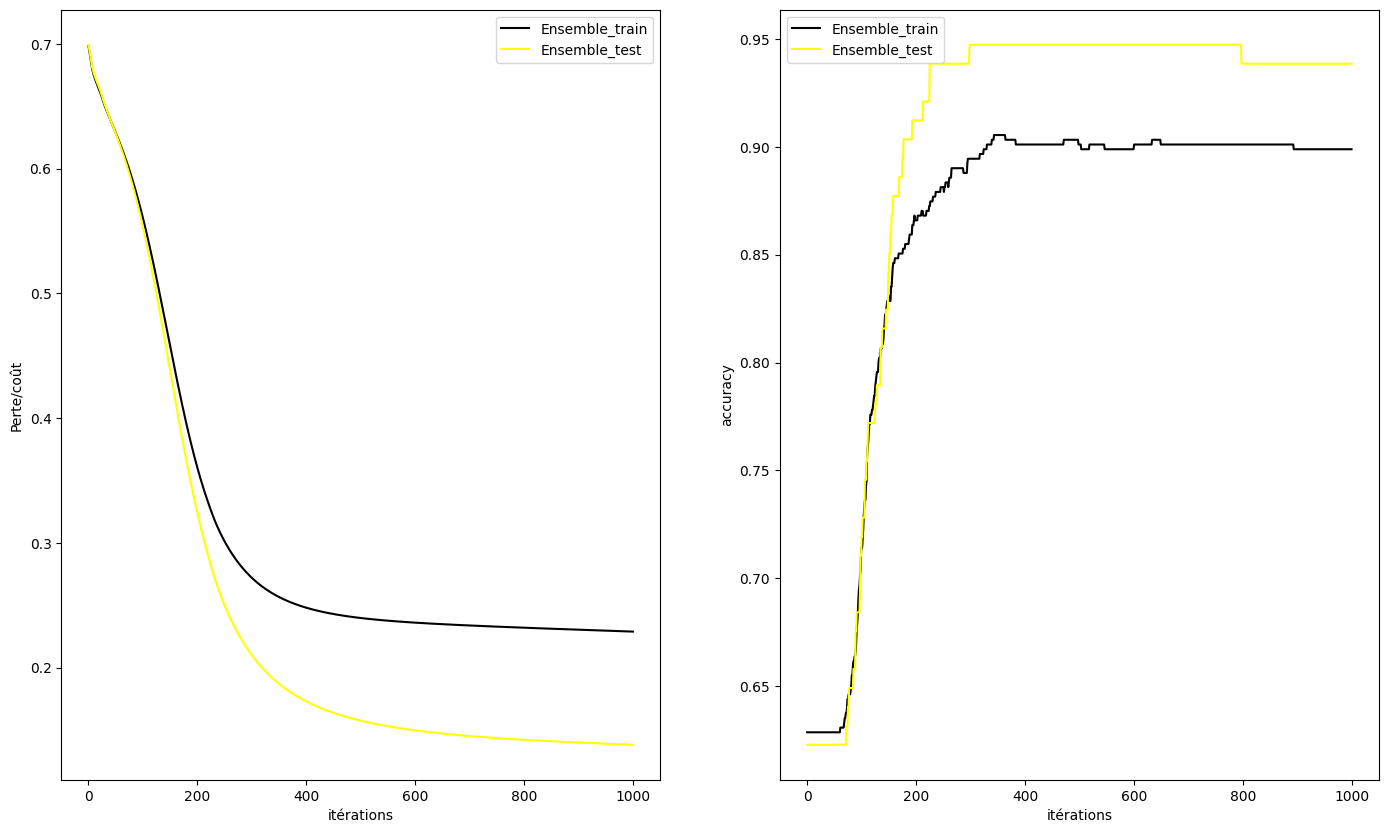

In [9]:
parametres = fit(X_train,X_test,y_train,y_test,16,16,0.01,10000)

100%|██████████| 10000/10000 [00:11<00:00, 867.67it/s]


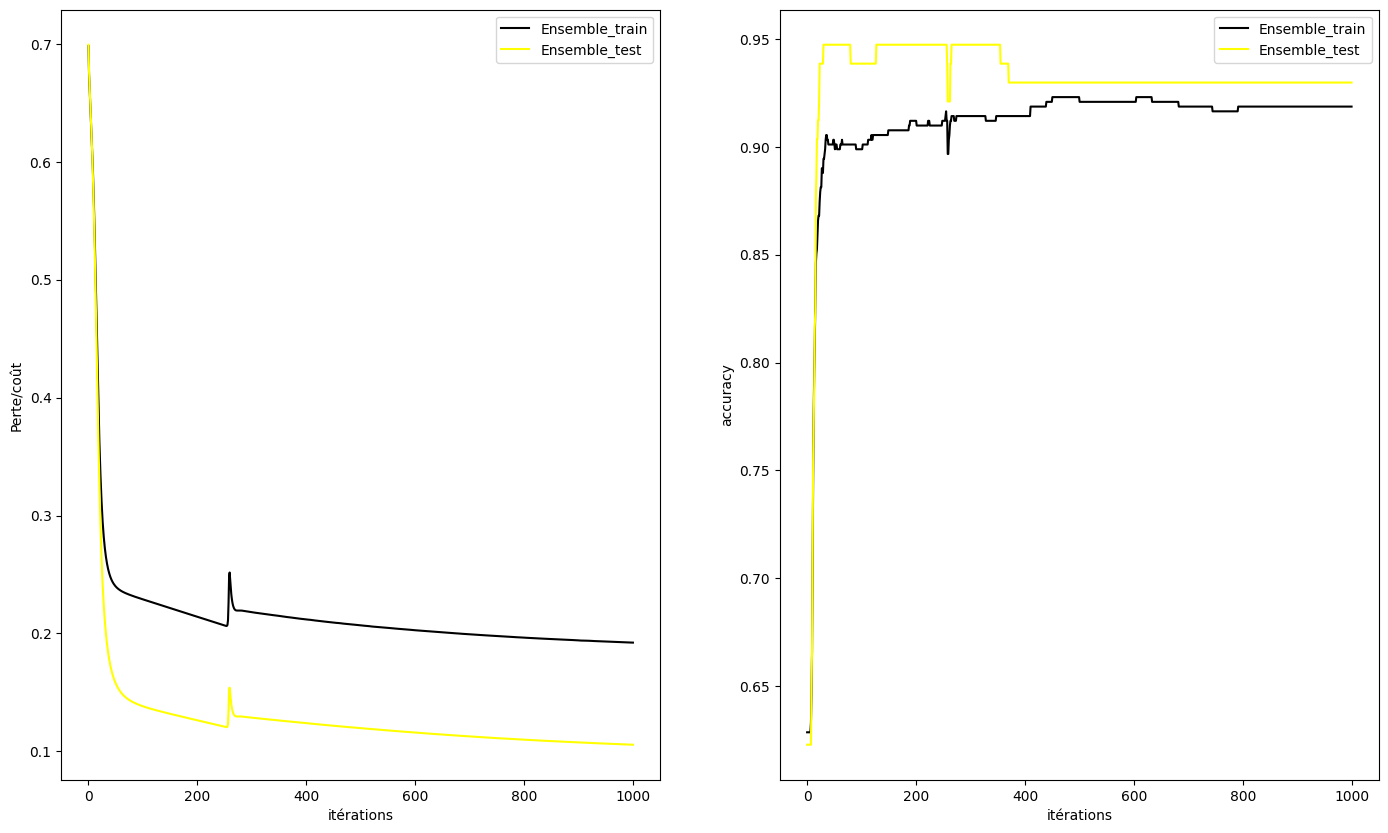

In [10]:
par1 = fit(X_train,X_test,y_train,y_test,16,16,0.1,10000)

100%|██████████| 10000/10000 [00:01<00:00, 5050.38it/s]


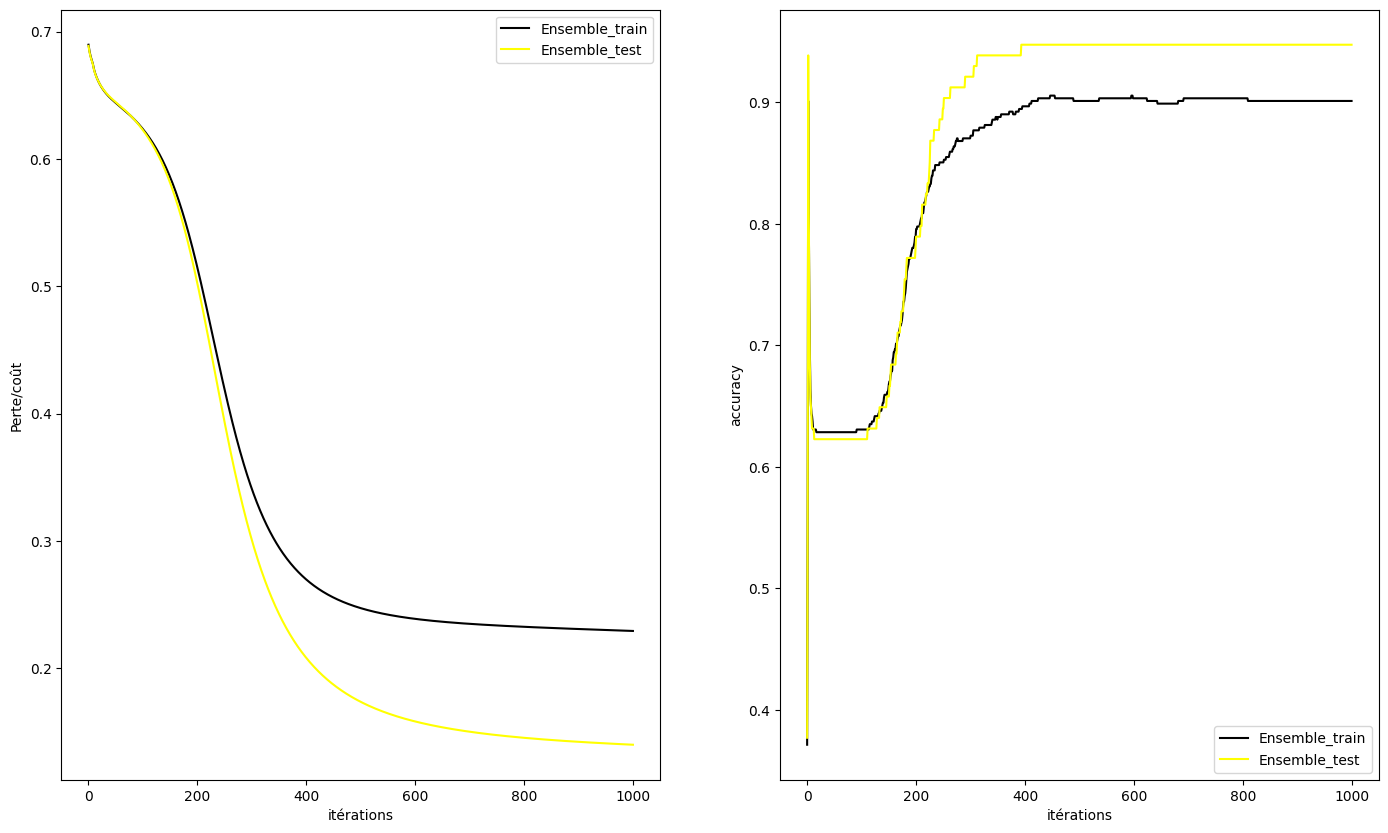

In [11]:
par3 = fit(X_train,X_test,y_train,y_test,8,8,0.01,10000)

100%|██████████| 10000/10000 [00:02<00:00, 3686.00it/s]


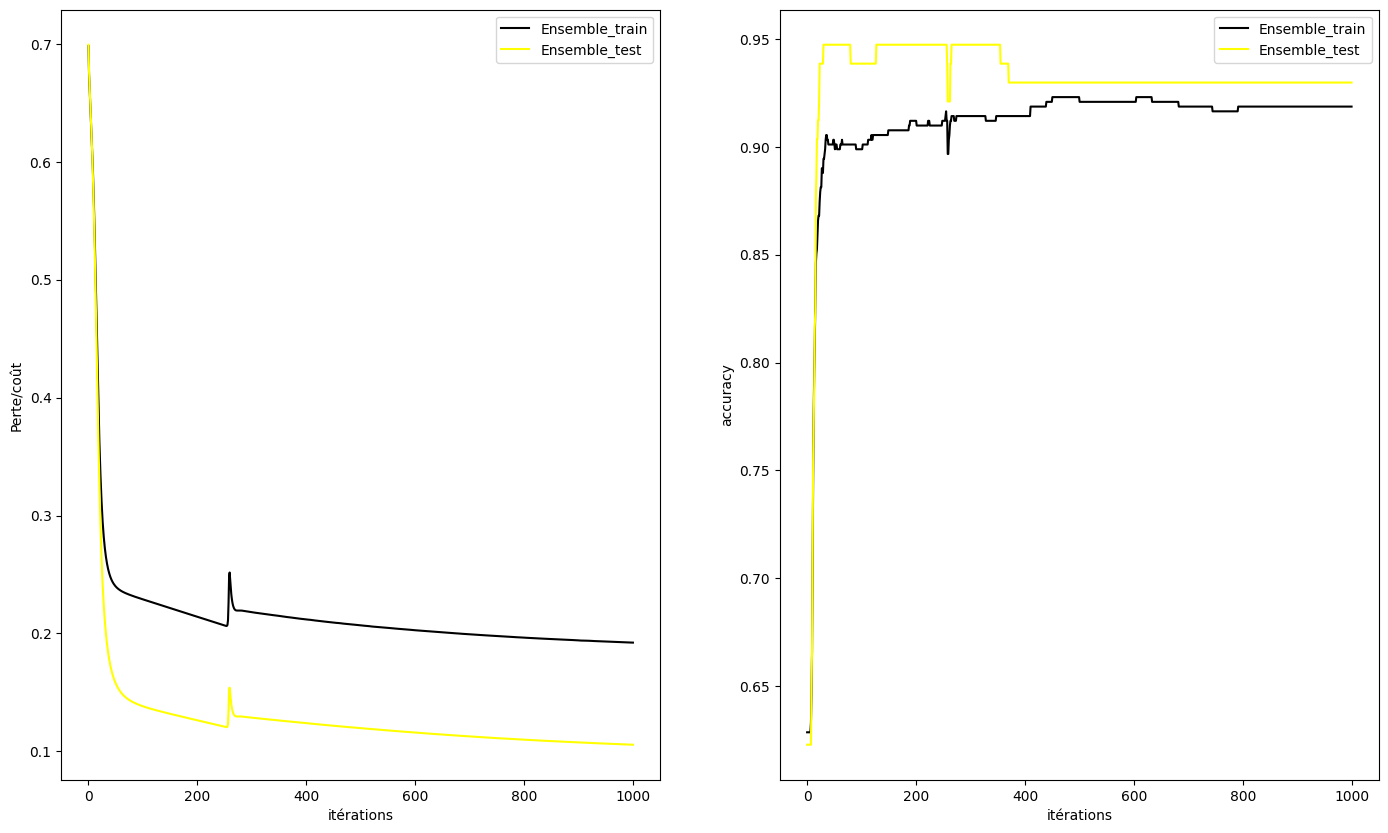

In [12]:
par4 = fit(X_train,X_test,y_train,y_test,16,16,0.1,10000)

100%|██████████| 10000/10000 [00:14<00:00, 690.17it/s]


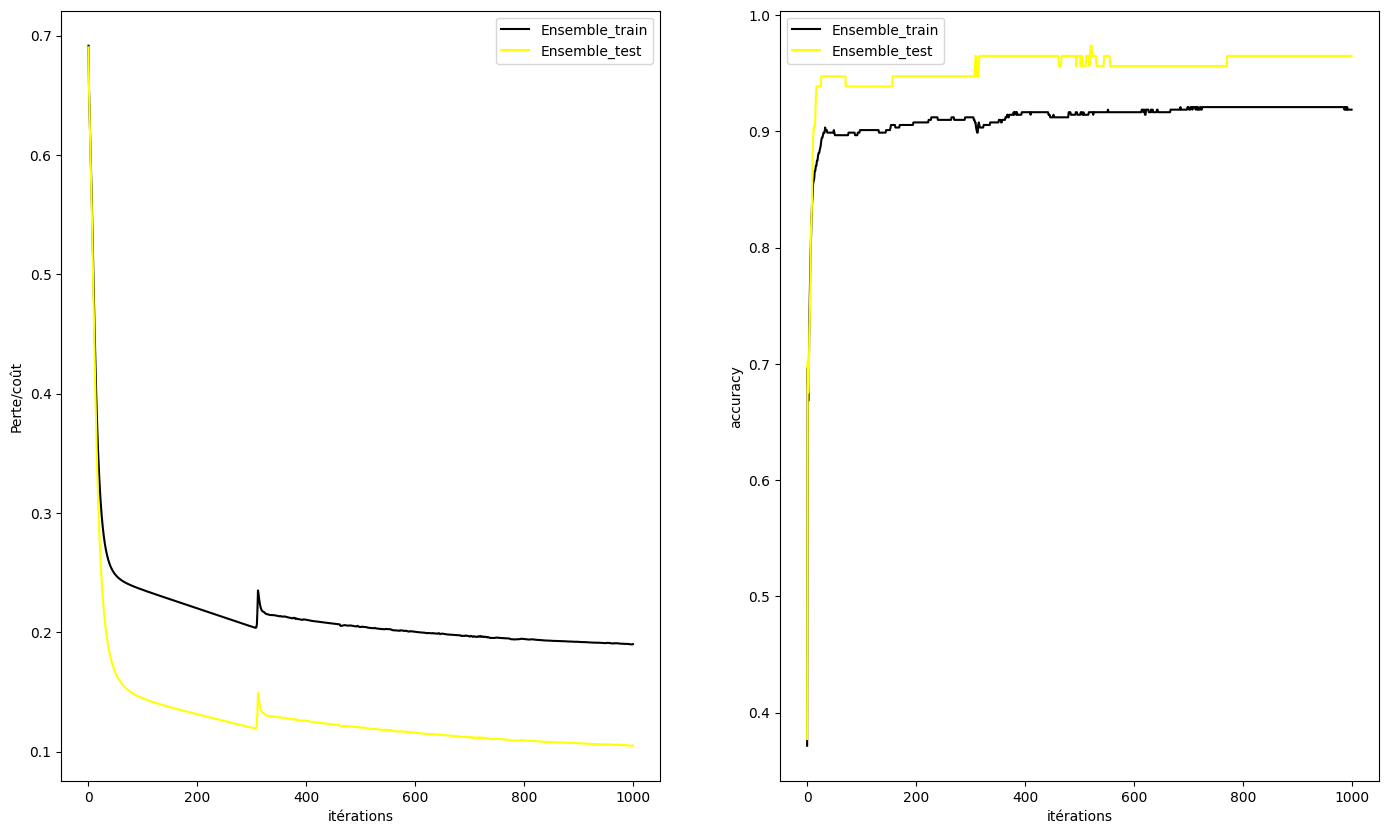

In [13]:
par5 = fit(X_train,X_test,y_train,y_test,64,64,0.1,10000)

100%|██████████| 100000/100000 [00:30<00:00, 3326.53it/s]


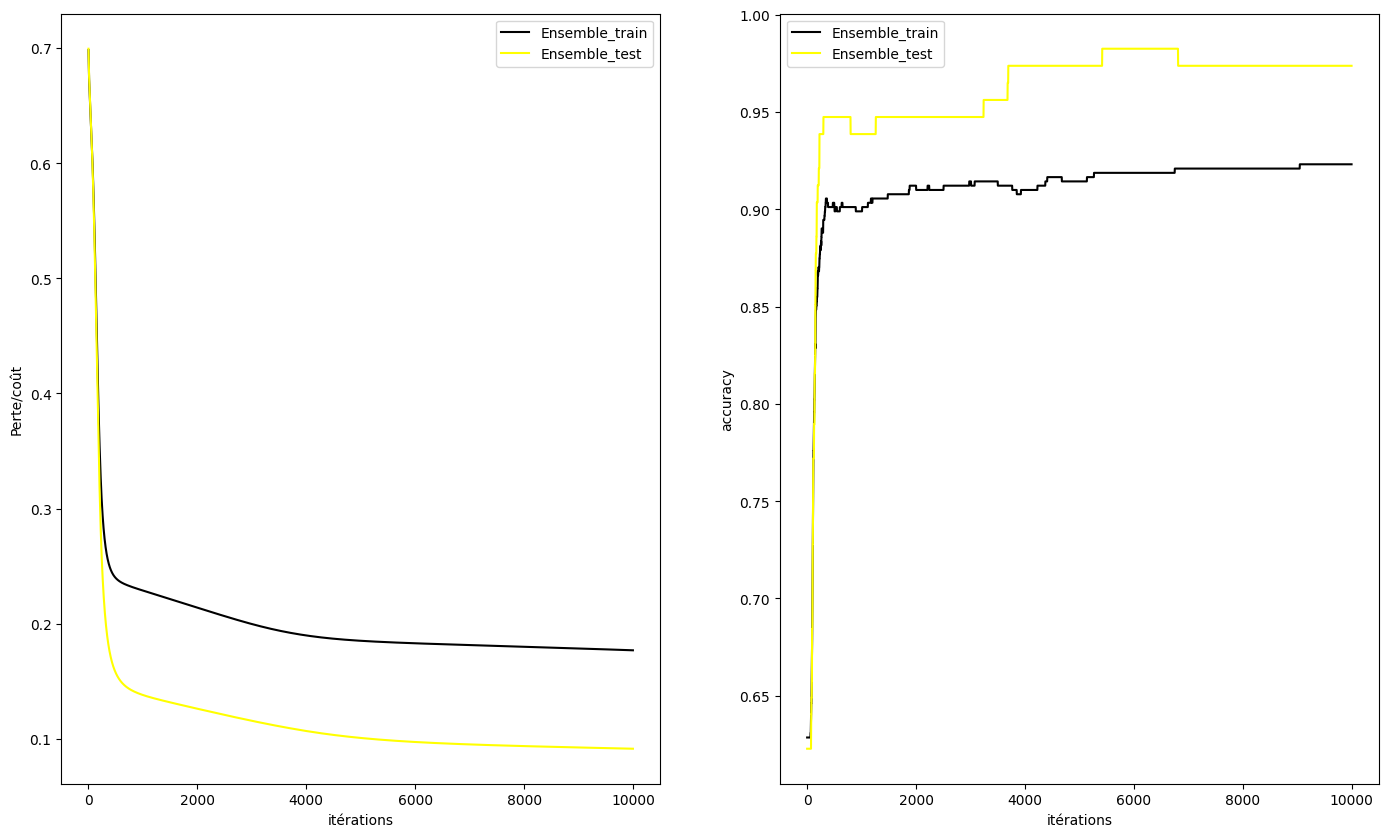

In [14]:
par6 = fit(X_train,X_test,y_train,y_test,16,16,0.01,100000)